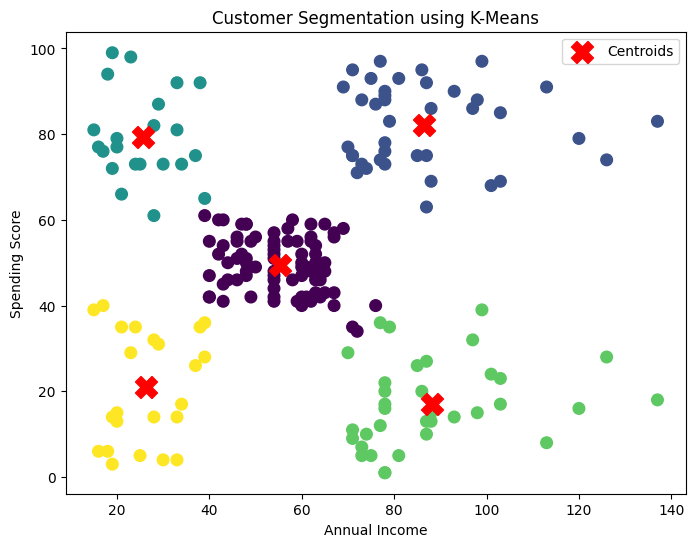

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load Dataset
df = pd.read_csv("Mall_Customers.csv")

# Select Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Train Model
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Add Cluster Labels
df['Cluster'] = kmeans.labels_

# Cluster Centers
centers = kmeans.cluster_centers_

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

In [4]:
# New customers: [Annual Income (k$), Spending Score (1-100)]
new_customers = pd.DataFrame({
    'Annual Income (k$)': [25, 60, 90],
    'Spending Score (1-100)': [80, 50, 20]
})

# Predict clusters
predicted_clusters = kmeans.predict(new_customers)

# Display results
new_customers['Predicted Cluster'] = predicted_clusters

print("\nNew Customer Predictions:")
print(new_customers)


New Customer Predictions:
   Annual Income (k$)  Spending Score (1-100)  Predicted Cluster
0                  25                      80                  2
1                  60                      50                  0
2                  90                      20                  3


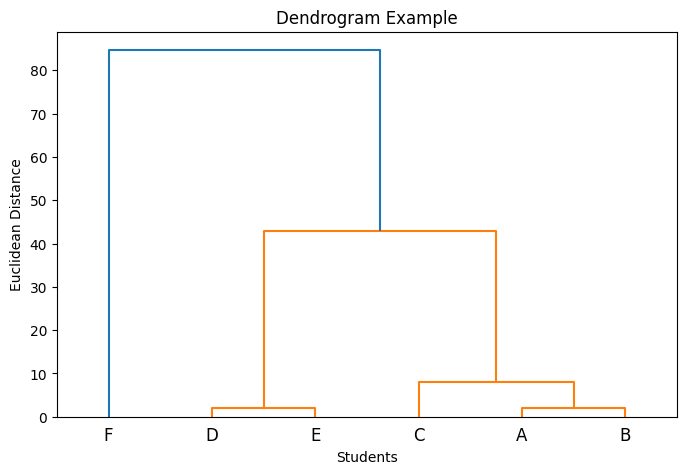

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# -----------------------------
# Create a Simple Dataset
# -----------------------------
df = pd.DataFrame({
    "Student": ["A", "B", "C", "D", "E", "F"],
    "Marks": [10, 12, 18, 40, 42, 90]
})

X = df[["Marks"]]

# -----------------------------
# Create Dendrogram
# -----------------------------
linked = linkage(X, method="ward")

plt.figure(figsize=(8,5))

dendrogram(
    linked,
    labels=df["Student"].values
)

plt.title("Dendrogram Example")
plt.xlabel("Students")
plt.ylabel("Euclidean Distance")

plt.show()

In [8]:
# Train Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)

df["Cluster"] = hc.fit_predict(X)

print(df)

  Student  Marks  Cluster
0       A     10        0
1       B     12        0
2       C     18        0
3       D     40        2
4       E     42        2
5       F     90        1


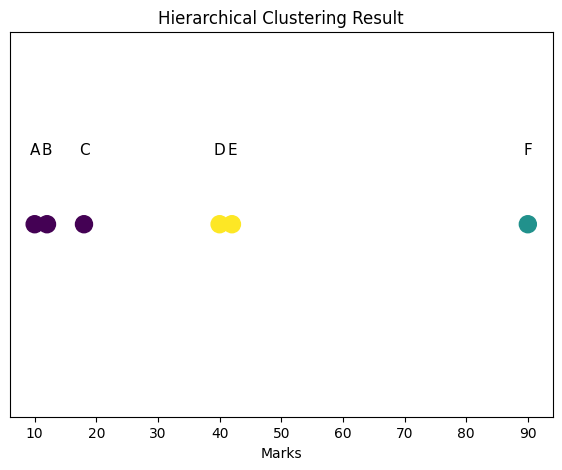

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(df["Marks"], [1]*len(df),
            c=df["Cluster"],
            cmap="viridis",
            s=150)

for i, row in df.iterrows():
    plt.text(row["Marks"], 1.02, row["Student"],
             ha="center", fontsize=11)

plt.yticks([])
plt.xlabel("Marks")
plt.title("Hierarchical Clustering Result")

plt.show()